In [5]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp
from scipy.stats import norm
from scipy.special import ndtri

## Load participant data and meta files 

In [6]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/localize_speech_in_elevation_v00/')
part_results = sorted(list(path_to_parts.glob("*.json")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/localize_speech_in_elevation_v00/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# get label to location map
with open(path_to_meta_data / "array_label_to_loc_dict.pkl", 'rb') as f:
    label_to_loc_map = pickle.load(f)

with open(path_to_meta_data / "array_loc_to_label_dict.pkl", 'rb') as f:
    loc_to_label_dict = pickle.load(f)

label_to_loc_map = {label: [loc[0], loc[1]] for label, loc in label_to_loc_map.items()}
# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:

    part_name = result_file.stem
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX. 
    part_ix = int(re.search(r'\d+', part_name).group())
    part_name_str = f"participant_{part_ix:03d}"
    # manifest_file = manifest_dict[part_name_str]
    # part_df = pd.read_csv(result_file)
    # part_df = part_df
    part_df = pd.read_json(result_file).T # T to transpose 
    part_df['true_label'] = part_df['locations'].apply(lambda x: loc_to_label_dict[(int(x[0][0]), int(x[0][1]))].lower())
    part_df['true_azimuth'], part_df['true_elevation'] = zip(*part_df['locations'].apply(lambda x: (x[0][0], x[0][1])).values)
    part_df['pred_azimuth'], part_df['pred_elevation'] = zip(*[label_to_loc_map[loc.upper()[:3]]for loc in part_df['response'].values])
    part_df['part_id'] = part_name_str
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)
results_df['accuracy'] = (results_df['response'] == results_df['true_label']).astype('int')
# convert columns to ints 
results_df['true_azimuth'] =     results_df['true_azimuth'].astype('int')
results_df['true_elevation'] =   results_df['true_elevation'].astype('int')
results_df['pred_azimuth'] =     results_df['pred_azimuth'].astype('int')
results_df['pred_elevation'] =   results_df['pred_elevation'].astype('int')

## Localization accuracy 

In [7]:
### Group by particiapnt 

summary_df = results_df.groupby(['part_id', 'true_label' ]).accuracy.mean().reset_index()
summary_df


,part_id,true_label,accuracy
0,participant_001,a10,0.666667
1,participant_001,a11,0.666667
2,participant_001,a16,0.966667
3,participant_001,a4,0.966667
4,participant_001,a9,0.666667
5,participant_001,b10,0.166667
6,participant_001,f10,0.433333
7,participant_001,g10,0.766667
8,participant_001,g11,0.766667
9,participant_001,g16,1.000000


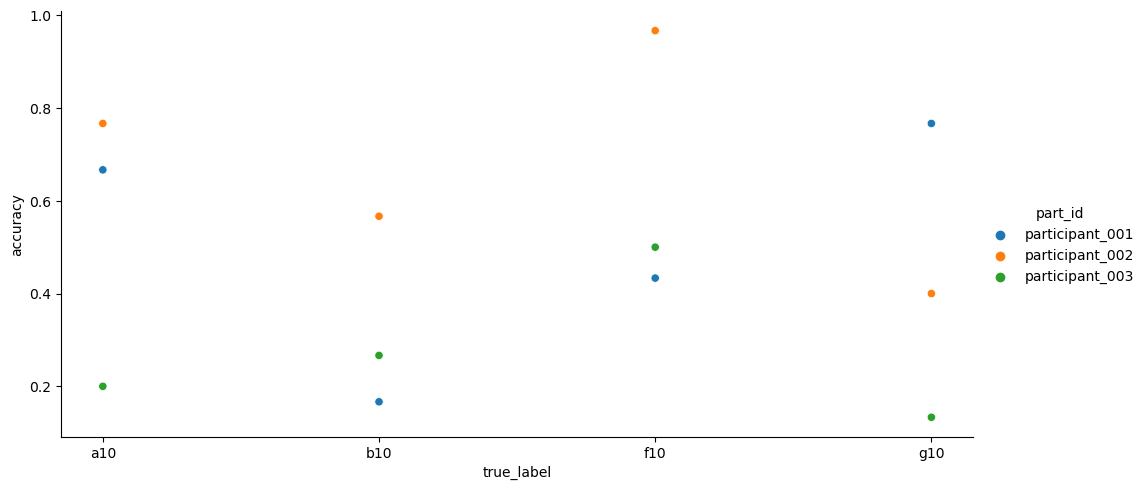

In [10]:
sns.relplot(data=summary_df[summary_df.true_label.str.contains('10')], x="true_label", y="accuracy", hue="part_id", aspect=2)

In [11]:
results_df

,trial_num,locations,response,true_label,true_azimuth,true_elevation,pred_azimuth,pred_elevation,part_id,accuracy
0,1,"[[0, -20]]",e10,g10,0,-20,0,0,participant_001,0
1,2,"[[10, 40]]",c10,a11,10,40,0,20,participant_001,0
2,3,"[[0, 40]]",a10,a10,0,40,0,40,participant_001,1
3,4,"[[10, 40]]",a11,a11,10,40,10,40,participant_001,1
4,5,"[[0, 40]]",a10,a10,0,40,0,40,participant_001,1
...,...,...,...,...,...,...,...,...,...,...
1075,356,"[[-60, 40]]",c4,a4,-60,40,-60,20,participant_003,0
1076,357,"[[0, -20]]",f10,g10,0,-20,0,-10,participant_003,0
1077,358,"[[0, 30]]",c10,b10,0,30,0,20,participant_003,0
1078,359,"[[0, -20]]",f10,g10,0,-20,0,-10,participant_003,0


In [12]:
results_df.true_azimuth.astype('int') == 0 

0        True
1       False
2        True
3       False
4        True
        ...  
1075    False
1076     True
1077     True
1078     True
1079    False
Name: true_azimuth, Length: 1080, dtype: bool

In [13]:
results_df[results_df.true_azimuth == 0]

,trial_num,locations,response,true_label,true_azimuth,true_elevation,pred_azimuth,pred_elevation,part_id,accuracy
0,1,"[[0, -20]]",e10,g10,0,-20,0,0,participant_001,0
2,3,"[[0, 40]]",a10,a10,0,40,0,40,participant_001,1
4,5,"[[0, 40]]",a10,a10,0,40,0,40,participant_001,1
5,6,"[[0, 40]]",a10,a10,0,40,0,40,participant_001,1
7,8,"[[0, 30]]",c10,b10,0,30,0,20,participant_001,0
...,...,...,...,...,...,...,...,...,...,...
1071,352,"[[0, 40]]",b10,a10,0,40,0,30,participant_003,0
1074,355,"[[0, 30]]",c10,b10,0,30,0,20,participant_003,0
1076,357,"[[0, -20]]",f10,g10,0,-20,0,-10,participant_003,0
1077,358,"[[0, 30]]",c10,b10,0,30,0,20,participant_003,0


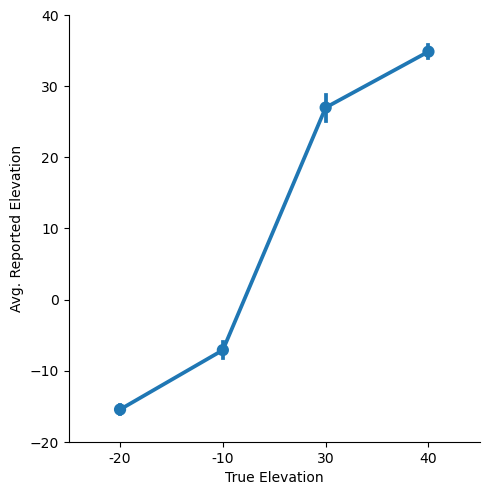

In [29]:
g = sns.catplot(data=results_df, kind='point',
             x='true_elevation', y='pred_elevation', 
            #   col='true_azimuth',
              errorbar=('se', 2))
# set limits
g.set(ylim=(-20, 40), ylabel='Avg. Reported Elevation', xlabel='True Elevation') 


-20 90
-10 90
30 90
40 90


[Text(0.5, 0, 'True elevation'), Text(0, 0.5, 'Reported elevation')]

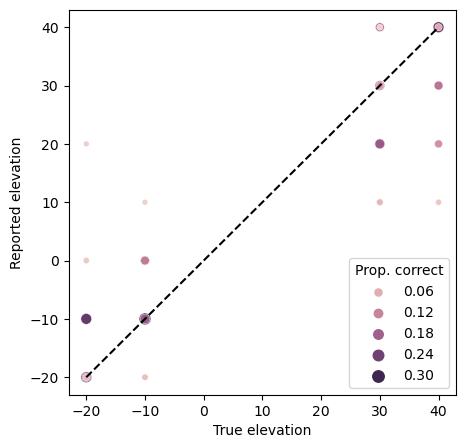

In [30]:
to_plot = results_df[results_df.true_azimuth==0]
to_plot = to_plot.groupby(['true_azimuth','true_elevation', 'pred_elevation', 'part_id']).count().reset_index()

for true_elev in to_plot.true_elevation.unique():
    elev_cond_ix = to_plot.true_elevation == true_elev
    elev_cond_trials = to_plot[elev_cond_ix]
    total_trials = elev_cond_trials.response.sum()
    print(true_elev, total_trials)
    to_plot.loc[elev_cond_ix, 'prop_hits'] = elev_cond_trials['response'].div(total_trials)

fig_dim = 5
fig, axs = plt.subplots(figsize=(fig_dim,fig_dim))
axs.plot(np.array([-20,-10, 30, 40]) , np.array([-20, -10, 30, 40]), 'k--')
g = sns.scatterplot(data=to_plot, x='true_elevation', y='pred_elevation',
                     hue='prop_hits', size='prop_hits',
                    #  sizes=(5,20),
                    #  hue_norm=(.1, .5),
                     ax=axs)
g.legend().set_title('Prop. correct')
g.set(xlabel='True elevation', ylabel='Reported elevation')





In [31]:
out_name = "/om2/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/screened_eval_trial_manifest_new_fnames_w_transcripts.pdpkl"
df = pd.read_pickle(out_name)   


360